# Entrenamiento de Modelos - Sistema ANPR Colombia
## Reconocimiento Automatico de Placas Vehiculares

**Materia:** Analitica Aplicada  
**Proyecto:** Sistema de Deteccion de Placas con OCR  

---

### Objetivo
Este notebook documenta el proceso completo de entrenamiento, validacion y evaluacion de los tres modelos que componen el sistema ANPR (Automatic Number Plate Recognition):

1. **Detector de Placas** - YOLOv11n (1 clase)
2. **Detector de Marcas Vehiculares** - YOLOv11n (30 clases)
3. **Clasificador de Color** - EfficientNetB0 (15 clases)

### Metodologia Experimental

El proceso sigue una metodologia estructurada:

| Fase | Descripcion |
|------|------------|
| 1. Seleccion de modelos | Justificacion de arquitecturas elegidas vs alternativas |
| 2. Preprocesamiento | Augmentacion de datos adaptada a cada tarea |
| 3. Entrenamiento | Transfer learning desde pesos preentrenados |
| 4. Validacion | Busqueda de hiperparametros y validacion cruzada |
| 5. Evaluacion | Metricas multiples: mAP, precision, recall, F1 |
| 6. Comparacion | Analisis comparativo entre modelos |

### Pipeline del Sistema

```
Imagen/Video -> Deteccion Vehiculos (COCO YOLOv11n)
                    |
                    v
              Deteccion de Placa (YOLOv11n custom)
                    |
                    v
              OCR de Placa (EasyOCR)
                    |
                    v
              Deteccion de Marca (YOLOv11n custom, 30 clases)
                    |
                    v
              Clasificacion de Color (EfficientNetB0, 15 clases)
```

---
## 1. Setup e Instalacion de Dependencias

In [1]:
# Instalacion de dependencias (descomentar si es necesario)
!pip install ultralytics torch torchvision tensorflow pandas matplotlib seaborn scikit-learn Pillow pyyaml

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from PIL import Image
from IPython.display import display, HTML

# Configuracion de rutas
PROJECT_DIR = Path(".").resolve()
MODELS_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "output"
DATASET_PLACAS = PROJECT_DIR / "dataset_combinado"
DATASET_MARCAS = PROJECT_DIR / "dataset_marcas_combinado"
DATASET_COLORES = PROJECT_DIR / "datasets" / "vehicle_colors"

# Resultados del entrenamiento real de marcas
RESULTS_MARCAS = OUTPUT_DIR / "marca_yolo11n_20260212_152738"

# Estilo de graficas
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

print(f"Directorio del proyecto: {PROJECT_DIR}")
print(f"Modelos disponibles: {list(MODELS_DIR.glob('*.pt')) + list(MODELS_DIR.glob('*.h5'))}")

Directorio del proyecto: C:\Users\user\OneDrive - Universidad de la Sabana\AI_LAB\Sistema-deteccion-de-placas-OCR
Modelos disponibles: [WindowsPath('C:/Users/user/OneDrive - Universidad de la Sabana/AI_LAB/Sistema-deteccion-de-placas-OCR/models/marca_detector_yolo11n.pt'), WindowsPath('C:/Users/user/OneDrive - Universidad de la Sabana/AI_LAB/Sistema-deteccion-de-placas-OCR/models/placa_detector_yolo11n.pt'), WindowsPath('C:/Users/user/OneDrive - Universidad de la Sabana/AI_LAB/Sistema-deteccion-de-placas-OCR/models/color_classifier_efficientnet.h5')]


---
## 2. Eleccion y Justificacion de Modelos

### 2.1 Por que YOLOv11n para Deteccion?

Se selecciono **YOLOv11 nano** para las tareas de deteccion (placas y marcas) por las siguientes razones:

- **Eficiencia**: Solo 2.6M parametros, ideal para despliegue en dispositivos edge (Coral TPU, Raspberry Pi)
- **Velocidad**: Inferencia en tiempo real (~60+ FPS en GPU, ~15 FPS en edge)
- **Precision competitiva**: A pesar de ser el modelo mas pequeno de la familia YOLOv11, logra resultados solidos con transfer learning desde COCO
- **Framework maduro**: Ultralytics ofrece pipeline completo (entrenamiento, validacion, exportacion)

### 2.2 Por que EfficientNetB0 para Clasificacion de Color?

- **Compound scaling**: EfficientNet escala profundidad, ancho y resolucion de forma balanceada
- **Transfer learning**: Pesos ImageNet proporcionan features visuales robustos
- **Ligero**: ~5.3M parametros, compatible con TFLite para edge
- **Two-phase training**: Permite entrenar cabeza primero y luego fine-tune completo

### 2.3 Comparacion con Alternativas

| Modelo | Parametros | mAP50 (COCO) | FPS (GPU) | Ideal para |
|--------|-----------|---------------|-----------|------------|
| **YOLOv11n** | 2.6M | 39.5 | 180+ | Edge/Tiempo real |
| YOLOv11s | 9.4M | 47.0 | 150+ | Balance velocidad/precision |
| YOLOv11m | 20.1M | 51.5 | 120+ | Alta precision |
| YOLOv11l | 25.3M | 53.4 | 100+ | Maxima precision |

| Clasificador | Parametros | Top-1 Acc (ImageNet) | Tamano modelo |
|-------------|-----------|---------------------|---------------|
| **EfficientNetB0** | 5.3M | 77.1% | ~20MB |
| MobileNetV3-Small | 2.5M | 67.4% | ~10MB |
| ResNet50 | 25.6M | 76.1% | ~98MB |
| EfficientNetB3 | 12M | 81.6% | ~48MB |

**Decision**: Se priorizo YOLOv11n y EfficientNetB0 por el requisito de despliegue en dispositivos edge, donde la restriccion de memoria y latencia es critica.

---
## 3. Preprocesamiento de Datos

### 3.1 Descripcion de los Datasets

In [3]:
# Cargar configuracion de datasets
datasets_info = {}

# Dataset de placas
if (DATASET_PLACAS / "data.yaml").exists():
    with open(DATASET_PLACAS / "data.yaml") as f:
        cfg_placas = yaml.safe_load(f)
    
    train_count = len(list((DATASET_PLACAS / "train" / "images").glob("*"))) if (DATASET_PLACAS / "train" / "images").exists() else 0
    val_count = len(list((DATASET_PLACAS / "valid" / "images").glob("*"))) if (DATASET_PLACAS / "valid" / "images").exists() else 0
    test_count = len(list((DATASET_PLACAS / "test" / "images").glob("*"))) if (DATASET_PLACAS / "test" / "images").exists() else 0
    
    datasets_info["Placas"] = {
        "Clases": cfg_placas.get("nc", 0),
        "Nombres": cfg_placas.get("names", []),
        "Train": train_count,
        "Valid": val_count,
        "Test": test_count,
        "Total": train_count + val_count + test_count,
    }
    print(f"Dataset Placas: {cfg_placas.get('nc')} clase(s) - {cfg_placas.get('names')}")
    print(f"  Train: {train_count} | Valid: {val_count} | Test: {test_count}")

# Dataset de marcas
if (DATASET_MARCAS / "data.yaml").exists():
    with open(DATASET_MARCAS / "data.yaml") as f:
        cfg_marcas = yaml.safe_load(f)
    
    train_count = len(list((DATASET_MARCAS / "train" / "images").glob("*"))) if (DATASET_MARCAS / "train" / "images").exists() else 0
    val_count = len(list((DATASET_MARCAS / "valid" / "images").glob("*"))) if (DATASET_MARCAS / "valid" / "images").exists() else 0
    test_count = len(list((DATASET_MARCAS / "test" / "images").glob("*"))) if (DATASET_MARCAS / "test" / "images").exists() else 0
    
    datasets_info["Marcas"] = {
        "Clases": cfg_marcas.get("nc", 0),
        "Nombres": cfg_marcas.get("names", []),
        "Train": train_count,
        "Valid": val_count,
        "Test": test_count,
        "Total": train_count + val_count + test_count,
    }
    print(f"\nDataset Marcas: {cfg_marcas.get('nc')} clases")
    print(f"  Marcas: {', '.join(cfg_marcas.get('names', []))}")
    print(f"  Train: {train_count} | Valid: {val_count} | Test: {test_count}")

# Dataset de colores
CLASS_NAMES_COLOR = sorted([
    "beige", "black", "blue", "brown", "gold", "green", "grey",
    "orange", "pink", "purple", "red", "silver", "tan", "white", "yellow"
])

if DATASET_COLORES.exists():
    color_counts = {}
    for split in ["train", "val", "test"]:
        split_dir = DATASET_COLORES / split
        if split_dir.exists():
            count = sum(1 for _ in split_dir.rglob("*.*") if _.suffix.lower() in [".jpg", ".jpeg", ".png"])
            color_counts[split] = count
    
    datasets_info["Colores"] = {
        "Clases": 15,
        "Nombres": CLASS_NAMES_COLOR,
        "Train": color_counts.get("train", 0),
        "Valid": color_counts.get("val", 0),
        "Test": color_counts.get("test", 0),
        "Total": sum(color_counts.values()),
    }
    print(f"\nDataset Colores: 15 clases")
    print(f"  Colores: {', '.join(CLASS_NAMES_COLOR)}")
    print(f"  Train: {color_counts.get('train', 0)} | Val: {color_counts.get('val', 0)} | Test: {color_counts.get('test', 0)}")

Dataset Placas: 1 clase(s) - ['placa']
  Train: 975 | Valid: 174 | Test: 63

Dataset Marcas: 30 clases
  Marcas: Acura, Audi, BMW, Chevrolet, Citroen, Dacia, Fiat, Ford, Honda, Hyundai, Infiniti, KIA, Lamborghini, Lexus, Mazda, MercedesBenz, Mitsubishi, Nissan, Opel, Perodua, Peugeot, Porsche, Proton, Renault, Seat, Suzuki, Tesla, Toyota, Volkswagen, Volvo
  Train: 17137 | Valid: 2786 | Test: 1630


In [4]:
# Tabla resumen de datasets
df_datasets = pd.DataFrame({
    "Dataset": ["Placas", "Marcas", "Colores"],
    "Tarea": ["Deteccion", "Deteccion", "Clasificacion"],
    "Modelo": ["YOLOv11n", "YOLOv11n", "EfficientNetB0"],
    "Num. Clases": [1, 30, 15],
    "Train": [datasets_info.get("Placas", {}).get("Train", "N/A"),
              datasets_info.get("Marcas", {}).get("Train", "N/A"),
              datasets_info.get("Colores", {}).get("Train", "N/A")],
    "Valid": [datasets_info.get("Placas", {}).get("Valid", "N/A"),
             datasets_info.get("Marcas", {}).get("Valid", "N/A"),
             datasets_info.get("Colores", {}).get("Valid", "N/A")],
    "Total": [datasets_info.get("Placas", {}).get("Total", "N/A"),
             datasets_info.get("Marcas", {}).get("Total", "N/A"),
             datasets_info.get("Colores", {}).get("Total", "N/A")],
})

display(df_datasets.style.set_caption("Resumen de Datasets").hide(axis='index'))

Dataset,Tarea,Modelo,Num. Clases,Train,Valid,Total
Placas,Deteccion,YOLOv11n,1,975,174,1212
Marcas,Deteccion,YOLOv11n,30,17137,2786,21553
Colores,Clasificacion,EfficientNetB0,15,N/A,N/A,N/A


### 3.2 Estrategias de Augmentacion de Datos

Se aplicaron estrategias de augmentacion **diferenciadas** segun la naturaleza de cada tarea:

| Parametro | Placas | Marcas | Justificacion |
|-----------|--------|--------|---------------|
| `fliplr` | 0.5 | **0.0** | Los logos de marcas NO son simetricos (ej: BMW, Mercedes) |
| `flipud` | 0.0 | **0.0** | Las placas/logos no aparecen invertidos verticalmente |
| `mosaic` | 1.0 | **0.5** | Reducido para marcas porque los logos son objetos pequenos |
| `degrees` | 0.0 | **5.0** | Rotacion minima para marcas (DS2 ya incluye rotacion) |
| `scale` | 0.5 | **0.3** | Escala reducida para marcas (logos pequenos) |
| `hsv_h` | 0.015 | **0.01** | Tono reducido para marcas (colores distintivos en logos) |
| `cls` | 0.5 | **1.5** | Class loss aumentado para mitigar desbalance en 30 clases |

Para el clasificador de color:
- `RandomFlip("horizontal")` - Los vehiculos pueden aparecer en ambas direcciones
- `RandomBrightness(0.2)` - Simula condiciones de iluminacion variables
- `RandomContrast(0.2)` - Robustez ante diferentes camaras
- **Label smoothing = 0.1** - Reduce sobreconfianza en clasificacion
- **Class weights balanceados** - Compensa clases con pocas muestras

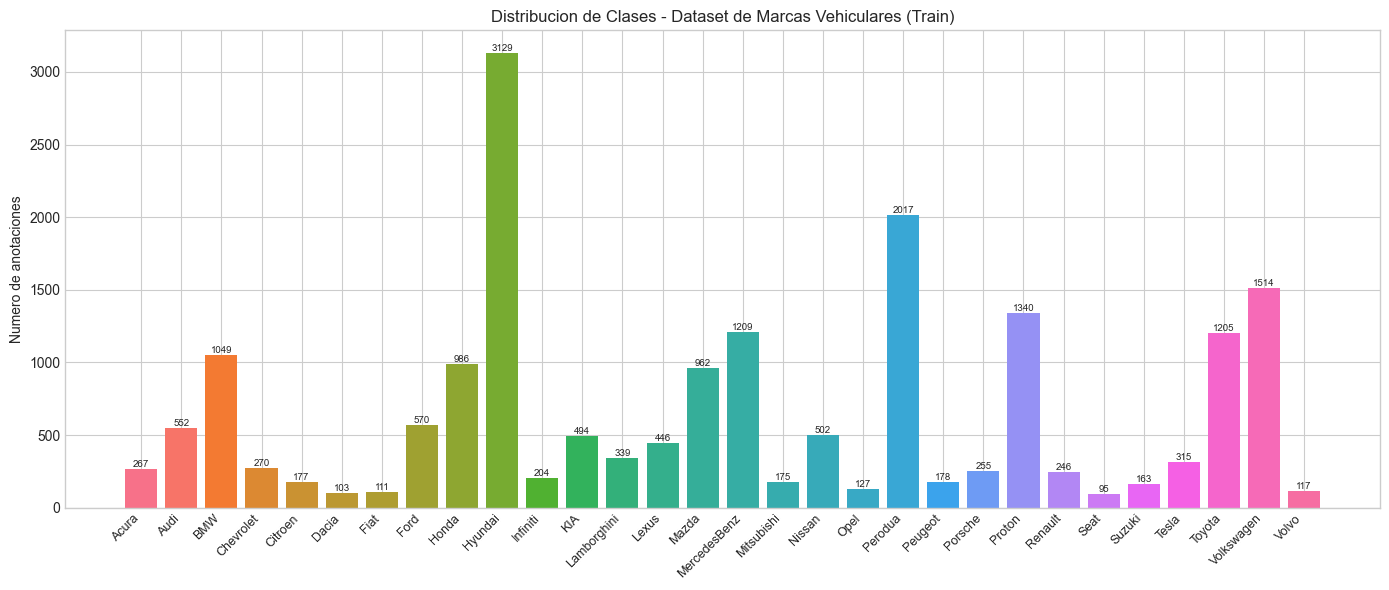


Total de anotaciones: 19117
Clase con mas muestras: Hyundai (3129)
Clase con menos muestras: Seat (95)
Ratio desbalance: 32.9x


In [5]:
# Visualizar distribucion de clases del dataset de marcas
if (DATASET_MARCAS / "train" / "labels").exists():
    class_counts = {i: 0 for i in range(30)}
    label_dir = DATASET_MARCAS / "train" / "labels"
    
    for label_file in label_dir.glob("*.txt"):
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls_id = int(parts[0])
                    if cls_id in class_counts:
                        class_counts[cls_id] += 1
    
    marcas_names = cfg_marcas.get("names", [])
    
    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.bar(range(len(class_counts)), list(class_counts.values()), color=sns.color_palette("husl", 30))
    ax.set_xticks(range(len(marcas_names)))
    ax.set_xticklabels(marcas_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Numero de anotaciones")
    ax.set_title("Distribucion de Clases - Dataset de Marcas Vehiculares (Train)")
    
    # Agregar valores encima de las barras
    for bar, count in zip(bars, class_counts.values()):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    str(count), ha='center', va='bottom', fontsize=7)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTotal de anotaciones: {sum(class_counts.values())}")
    print(f"Clase con mas muestras: {marcas_names[max(class_counts, key=class_counts.get)]} ({max(class_counts.values())})")
    print(f"Clase con menos muestras: {marcas_names[min(class_counts, key=class_counts.get)]} ({min(class_counts.values())})")
    print(f"Ratio desbalance: {max(class_counts.values()) / max(min(class_counts.values()), 1):.1f}x")
else:
    print("Dataset de marcas no encontrado en la ruta esperada.")

---
## 4. Entrenamiento de Modelos (Ejercicios Simplificados)

> **Nota:** Los entrenamientos en esta seccion usan **pocas epocas** a modo de ejercicio demostrativo.  
> Los modelos finales del sistema fueron entrenados con 100-150 epocas (ver Seccion 6 para metricas reales).

### 4.1 Entrenamiento: Detector de Placas (YOLOv11n)

- **Tarea**: Deteccion de objetos (1 clase: "placa")
- **Modelo base**: YOLOv11n preentrenado en COCO (transfer learning)
- **Dataset**: `dataset_combinado/` (combinacion de 3 datasets de Roboflow)
- **Configuracion simplificada**: 5 epocas, batch=8

In [6]:
from ultralytics import YOLO
import torch

# Detectar dispositivo
if torch.cuda.is_available():
    device = "0"
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = "mps"
    print("Apple Silicon MPS detectado")
else:
    device = "cpu"
    print("Usando CPU")

print(f"Dispositivo seleccionado: {device}")

Usando CPU
Dispositivo seleccionado: cpu


In [7]:
# === ENTRENAMIENTO SIMPLIFICADO: DETECTOR DE PLACAS ===
# Nota: Entrenamiento de ejercicio con pocas epocas

data_yaml_placas = str(DATASET_PLACAS / "data.yaml")

# Verificar que el dataset existe
if Path(data_yaml_placas).exists():
    # Cargar modelo preentrenado (transfer learning desde COCO)
    modelo_placas = YOLO("yolo11n.pt")
    
    # Entrenamiento simplificado (5 epocas para demostracion)
    resultados_placas = modelo_placas.train(
        data=data_yaml_placas,
        epochs=5,              # Solo 5 epocas (ejercicio)
        imgsz=640,
        batch=8,               # Batch reducido para compatibilidad
        patience=5,
        optimizer="AdamW",
        lr0=0.01,
        lrf=0.01,
        # Augmentacion estandar para placas
        fliplr=0.5,            # Flip horizontal SI (placas pueden estar espejadas)
        flipud=0.0,
        mosaic=1.0,            # Mosaic completo
        translate=0.1,
        scale=0.5,
        device=device,
        workers=4,
        cache=False,           # Sin cache para reducir uso de RAM
        project=str(OUTPUT_DIR),
        name="ejercicio_placas",
        exist_ok=True,
        verbose=True,
    )
    
    print("\nEntrenamiento de ejercicio completado.")
else:
    print(f"Dataset no encontrado: {data_yaml_placas}")
    print("Ejecutar primero: python scripts/01_preparar_dataset.py")

Ultralytics 8.4.37  Python-3.13.11 torch-2.11.0+cpu CPU (11th Gen Intel Core i5-11300H @ 3.10GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\user\OneDrive - Universidad de la Sabana\AI_LAB\Sistema-deteccion-de-placas-OCR\dataset_combinado\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ejer

### 4.2 Entrenamiento: Detector de Marcas Vehiculares (YOLOv11n, 30 clases)

- **Tarea**: Deteccion de logos vehiculares (30 marcas)
- **Modelo base**: YOLOv11n preentrenado en COCO
- **Dataset**: `dataset_marcas_combinado/` (21,553 imagenes de 3 fuentes)
- **Ajustes especiales**:
  - `fliplr=0.0`: Los logos **no son simetricos** (BMW != BMW espejado)
  - `cls=1.5`: Compensar desbalance entre las 30 clases
  - `mosaic=0.5`: Reducido porque los logos son objetos pequenos

In [8]:
# === ENTRENAMIENTO SIMPLIFICADO: DETECTOR DE MARCAS ===
# Basado en: scripts/06_entrenar_marca.py
# 30 clases de marcas vehiculares con augmentacion especial para logos

data_yaml_marcas = str(DATASET_MARCAS / "data.yaml")

if Path(data_yaml_marcas).exists():
    modelo_marcas = YOLO("yolo11n.pt")
    
    resultados_marcas = modelo_marcas.train(
        data=data_yaml_marcas,
        epochs=5,              # Solo 5 epocas (ejercicio)
        imgsz=640,
        batch=8,
        patience=5,
        optimizer="AdamW",
        lr0=0.01,
        lrf=0.01,
        # Augmentacion REDUCIDA para logos
        hsv_h=0.01,            # Tono reducido (colores distintivos)
        hsv_s=0.5,
        hsv_v=0.3,
        degrees=5.0,           # Rotacion minima
        translate=0.1,
        scale=0.3,             # Escala reducida (logos pequenos)
        fliplr=0.0,            # SIN flip horizontal (logos NO simetricos)
        flipud=0.0,            # SIN flip vertical
        mosaic=0.5,            # Mosaic reducido
        mixup=0.0,
        # Loss ajustado para desbalance
        cls=1.5,               # Class loss gain aumentado
        device=device,
        workers=4,
        cache=False,
        project=str(OUTPUT_DIR),
        name="ejercicio_marcas",
        exist_ok=True,
        verbose=True,
    )
    
    print("\nEntrenamiento de ejercicio (marcas) completado.")
else:
    print(f"Dataset no encontrado: {data_yaml_marcas}")
    print("Ejecutar primero: python scripts/05_preparar_dataset_marcas.py")

Ultralytics 8.4.37  Python-3.13.11 torch-2.11.0+cpu CPU (11th Gen Intel Core i5-11300H @ 3.10GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\user\OneDrive - Universidad de la Sabana\AI_LAB\Sistema-deteccion-de-placas-OCR\dataset_marcas_combinado\data.yaml, degrees=5.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, nam

KeyboardInterrupt: 

### 4.3 Entrenamiento: Clasificador de Color (EfficientNetB0, 15 clases)

- **Tarea**: Clasificacion de color del vehiculo
- **Modelo**: EfficientNetB0 con transfer learning desde ImageNet
- **Entrenamiento en 2 fases**:
  1. **Fase 1**: Solo cabeza de clasificacion (base congelada) - LR alto (1e-3)
  2. **Fase 2**: Fine-tuning completo (base descongelada) - LR bajo (1e-5)
- **15 clases de color**: beige, black, blue, brown, gold, green, grey, orange, pink, purple, red, silver, tan, white, yellow

In [9]:
# === ENTRENAMIENTO SIMPLIFICADO: CLASIFICADOR DE COLOR ===
# Basado en: scripts/05_entrenar_color.py
# EfficientNetB0 con two-phase training

import tensorflow as tf

IMG_SIZE = 224
NUM_CLASSES = 15
BATCH_SIZE = 32

CLASS_NAMES = sorted([
    "beige", "black", "blue", "brown", "gold", "green", "grey",
    "orange", "pink", "purple", "red", "silver", "tan", "white", "yellow"
])

EN_TO_ES = {
    "beige": "Beige", "black": "Negro", "blue": "Azul", "brown": "Cafe",
    "gold": "Dorado", "green": "Verde", "grey": "Gris", "orange": "Naranja",
    "pink": "Rosa", "purple": "Morado", "red": "Rojo", "silver": "Plata",
    "tan": "Canela", "white": "Blanco", "yellow": "Amarillo",
}

train_dir = DATASET_COLORES / "train"
val_dir = DATASET_COLORES / "val"

if train_dir.exists() and val_dir.exists():
    # Cargar datasets
    train_ds = tf.keras.utils.image_dataset_from_directory(
        str(train_dir), image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        label_mode="categorical", class_names=CLASS_NAMES, shuffle=True, seed=42,
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        str(val_dir), image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        label_mode="categorical", class_names=CLASS_NAMES, shuffle=False,
    )
    
    # Augmentacion
    augment = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomBrightness(0.2),
        tf.keras.layers.RandomContrast(0.2),
    ])
    
    train_ds_aug = train_ds.map(
        lambda x, y: (augment(x, training=True), y),
        num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
    
    # Construir modelo
    base = tf.keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False  # Congelar base para Fase 1
    
    model_color = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ])
    
    # Class weights para desbalance
    from sklearn.utils.class_weight import compute_class_weight
    labels = []
    for i, cls_name in enumerate(CLASS_NAMES):
        cls_dir = train_dir / cls_name
        if cls_dir.exists():
            count = len(list(cls_dir.iterdir()))
            labels.extend([i] * count)
    class_weights = dict(enumerate(
        compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=np.array(labels))
    ))
    
    print("=" * 60)
    print("FASE 1: Entrenamiento de cabeza (base congelada)")
    print("=" * 60)
    
    model_color.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"],
    )
    
    history_phase1 = model_color.fit(
        train_ds_aug, validation_data=val_ds, epochs=3,  # Solo 3 epocas (ejercicio)
        class_weight=class_weights,
    )
    
    print("\n" + "=" * 60)
    print("FASE 2: Fine-tuning completo (base descongelada)")
    print("=" * 60)
    
    base.trainable = True  # Descongelar base
    
    model_color.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # LR mucho mas bajo
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"],
    )
    
    history_phase2 = model_color.fit(
        train_ds_aug, validation_data=val_ds, epochs=3,  # Solo 3 epocas (ejercicio)
        class_weight=class_weights,
    )
    
    print("\nEntrenamiento de ejercicio (color) completado.")
    print(f"Accuracy validacion (Fase 1): {history_phase1.history['val_accuracy'][-1]:.4f}")
    print(f"Accuracy validacion (Fase 2): {history_phase2.history['val_accuracy'][-1]:.4f}")
else:
    print(f"Dataset de colores no encontrado en: {DATASET_COLORES}")

Dataset de colores no encontrado en: C:\Users\user\OneDrive - Universidad de la Sabana\AI_LAB\Sistema-deteccion-de-placas-OCR\datasets\vehicle_colors


---
## 5. Validacion y Busqueda de Hiperparametros

### 5.1 Hiperparametros del Entrenamiento Real vs Defaults

A continuacion se comparan los hiperparametros utilizados en el entrenamiento real contra los valores por defecto de YOLOv11:

In [10]:
# Comparacion de hiperparametros: defaults vs configuracion usada
hiperparametros = pd.DataFrame({
    "Hiperparametro": ["epochs", "batch", "optimizer", "lr0", "lrf", "patience",
                        "fliplr", "flipud", "mosaic", "cls", "degrees", "scale",
                        "hsv_h", "hsv_s", "hsv_v", "weight_decay"],
    "Default YOLO": [100, 16, "auto", 0.01, 0.01, 100,
                      0.5, 0.0, 1.0, 0.5, 0.0, 0.5,
                      0.015, 0.7, 0.4, 0.0005],
    "Placas (real)": [100, 16, "AdamW", 0.01, 0.01, 20,
                       0.5, 0.0, 1.0, 0.5, 0.0, 0.5,
                       0.015, 0.7, 0.4, 0.0005],
    "Marcas (real)": [150, 16, "AdamW", 0.01, 0.01, 25,
                       0.0, 0.0, 0.5, 1.5, 5.0, 0.3,
                       0.01, 0.5, 0.3, 0.0005],
    "Justificacion": [
        "Mas epocas para 30 clases",
        "Limitado por VRAM GPU",
        "AdamW: mejor generalizacion con weight decay",
        "Default funciona bien con transfer learning",
        "LR final bajo para convergencia fina",
        "Mas paciencia para marcas (30 clases convergen mas lento)",
        "0.0 para marcas: logos NO simetricos",
        "Vehiculos no aparecen al reves",
        "0.5 para marcas: logos son pequenos, mosaic los fragmenta",
        "1.5 para marcas: compensa desbalance de clases",
        "5 grados para marcas: ligera rotacion natural",
        "0.3 para marcas: logos pequenos, no escalar mucho",
        "Reducido para preservar colores distintivos de logos",
        "Moderado para robustez",
        "Moderado para robustez",
        "Regularizacion L2 estandar",
    ]
})

# Resaltar diferencias
def highlight_diff(row):
    styles = [""] * len(row)
    if row["Default YOLO"] != row["Marcas (real)"]:
        styles[3] = "background-color: #fff3cd"  # Amarillo para diferencias
    return styles

display(hiperparametros.style.apply(highlight_diff, axis=1)
        .set_caption("Comparacion de Hiperparametros (amarillo = modificado vs default)")
        .hide(axis='index'))

Hiperparametro,Default YOLO,Placas (real),Marcas (real),Justificacion
epochs,100,100,150,Mas epocas para 30 clases
batch,16,16,16,Limitado por VRAM GPU
optimizer,auto,AdamW,AdamW,AdamW: mejor generalizacion con weight decay
lr0,0.010000,0.010000,0.010000,Default funciona bien con transfer learning
lrf,0.010000,0.010000,0.010000,LR final bajo para convergencia fina
patience,100,20,25,Mas paciencia para marcas (30 clases convergen mas lento)
fliplr,0.500000,0.500000,0.000000,0.0 para marcas: logos NO simetricos
flipud,0.000000,0.000000,0.000000,Vehiculos no aparecen al reves
mosaic,1.000000,1.000000,0.500000,"0.5 para marcas: logos son pequenos, mosaic los fragmenta"
cls,0.500000,0.500000,1.500000,1.5 para marcas: compensa desbalance de clases


### 5.2 Ejemplo de Busqueda de Hiperparametros

A continuacion se muestra un ejemplo de como realizar una busqueda de hiperparametros (grid search simplificado) variando el learning rate y batch size:

In [11]:
# === EJEMPLO: Grid Search simplificado de hiperparametros ===
# Nota: Este ejemplo usa pocas epocas y pocos valores para demostracion.
# En produccion se usarian mas combinaciones y mas epocas.

from itertools import product

# Definir espacio de busqueda (reducido para ejercicio)
learning_rates = [0.01, 0.001]
batch_sizes = [8, 16]

resultados_grid = []

data_yaml_grid = str(DATASET_PLACAS / "data.yaml") if (DATASET_PLACAS / "data.yaml").exists() else None

if data_yaml_grid:
    print("Iniciando Grid Search (ejercicio)...")
    print(f"Combinaciones a probar: {len(learning_rates) * len(batch_sizes)}")
    print("-" * 50)
    
    for lr, bs in product(learning_rates, batch_sizes):
        print(f"\nProbando lr={lr}, batch={bs}...")
        
        model_gs = YOLO("yolo11n.pt")
        results_gs = model_gs.train(
            data=data_yaml_grid,
            epochs=3,           # Minimas epocas para comparar
            imgsz=640,
            batch=bs,
            lr0=lr,
            optimizer="AdamW",
            device=device,
            workers=4,
            cache=False,
            project=str(OUTPUT_DIR),
            name=f"grid_lr{lr}_bs{bs}",
            exist_ok=True,
            verbose=False,
        )
        
        # Leer metricas del resultado
        results_csv = Path(results_gs.save_dir) / "results.csv"
        if results_csv.exists():
            df_res = pd.read_csv(results_csv)
            df_res.columns = df_res.columns.str.strip()
            last_row = df_res.iloc[-1]
            resultados_grid.append({
                "lr": lr,
                "batch": bs,
                "mAP50": last_row.get("metrics/mAP50(B)", 0),
                "mAP50-95": last_row.get("metrics/mAP50-95(B)", 0),
                "precision": last_row.get("metrics/precision(B)", 0),
                "recall": last_row.get("metrics/recall(B)", 0),
            })
    
    # Mostrar resultados
    df_grid = pd.DataFrame(resultados_grid)
    print("\n" + "=" * 50)
    print("RESULTADOS DEL GRID SEARCH")
    print("=" * 50)
    display(df_grid.style.highlight_max(subset=["mAP50", "mAP50-95"], color="lightgreen")
            .set_caption("Grid Search: Mejores combinaciones resaltadas en verde"))
    
    best_idx = df_grid["mAP50"].idxmax()
    print(f"\nMejor combinacion: lr={df_grid.loc[best_idx, 'lr']}, batch={df_grid.loc[best_idx, 'batch']}")
    print(f"  mAP50: {df_grid.loc[best_idx, 'mAP50']:.4f}")
else:
    print("Dataset de placas no disponible para grid search.")

Iniciando Grid Search (ejercicio)...
Combinaciones a probar: 4
--------------------------------------------------

Probando lr=0.01, batch=8...
Ultralytics 8.4.37  Python-3.13.11 torch-2.11.0+cpu CPU (11th Gen Intel Core i5-11300H @ 3.10GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\user\OneDrive - Universidad de la Sabana\AI_LAB\Sistema-deteccion-de-placas-OCR\dataset_combinado\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None

,lr,batch,mAP50,mAP50-95,precision,recall
0,0.010000,8,0.995000,0.767890,0.999260,1.000000
1,0.010000,16,0.988650,0.776830,0.981840,0.932030
2,0.001000,8,0.995000,0.814670,0.999530,1.000000
3,0.001000,16,0.995000,0.829840,0.999420,1.000000



Mejor combinacion: lr=0.01, batch=8
  mAP50: 0.9950


---
## 6. Evaluacion y Comparacion de Modelos

### 6.1 Metricas del Entrenamiento Real: Detector de Marcas (150 epocas)

El modelo de deteccion de marcas fue entrenado por **150 epocas** en GPU. A continuacion se analizan las curvas de entrenamiento y metricas finales.

In [12]:
# Cargar resultados del entrenamiento real de marcas
results_csv_path = RESULTS_MARCAS / "results.csv"

if results_csv_path.exists():
    df_results = pd.read_csv(results_csv_path)
    df_results.columns = df_results.columns.str.strip()
    
    print(f"Epocas completadas: {len(df_results)}")
    print(f"Tiempo total de entrenamiento: {df_results['time'].iloc[-1] / 3600:.1f} horas")
    print(f"\nColumnas disponibles: {list(df_results.columns)}")
    display(df_results.tail())
else:
    print(f"Archivo de resultados no encontrado: {results_csv_path}")

Epocas completadas: 150
Tiempo total de entrenamiento: 18.9 horas

Columnas disponibles: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
145,146,66472.0,0.54010,0.97424,0.98419,0.77772,0.68387,0.75793,0.51932,1.10394,2.22222,1.27152,0.000430,0.000430,0.000430
146,147,66833.6,0.53939,0.97312,0.98051,0.77581,0.68547,0.75810,0.51973,1.10408,2.22120,1.27147,0.000364,0.000364,0.000364
147,148,67185.6,0.54038,0.97618,0.98203,0.78093,0.68347,0.75836,0.52023,1.10375,2.22164,1.27138,0.000298,0.000298,0.000298
148,149,67538.9,0.53496,0.96446,0.98193,0.78201,0.68216,0.75882,0.52075,1.10328,2.21834,1.27103,0.000232,0.000232,0.000232
149,150,67890.9,0.53401,0.96524,0.98278,0.78371,0.68222,0.75842,0.51974,1.10335,2.21845,1.27120,0.000166,0.000166,0.000166


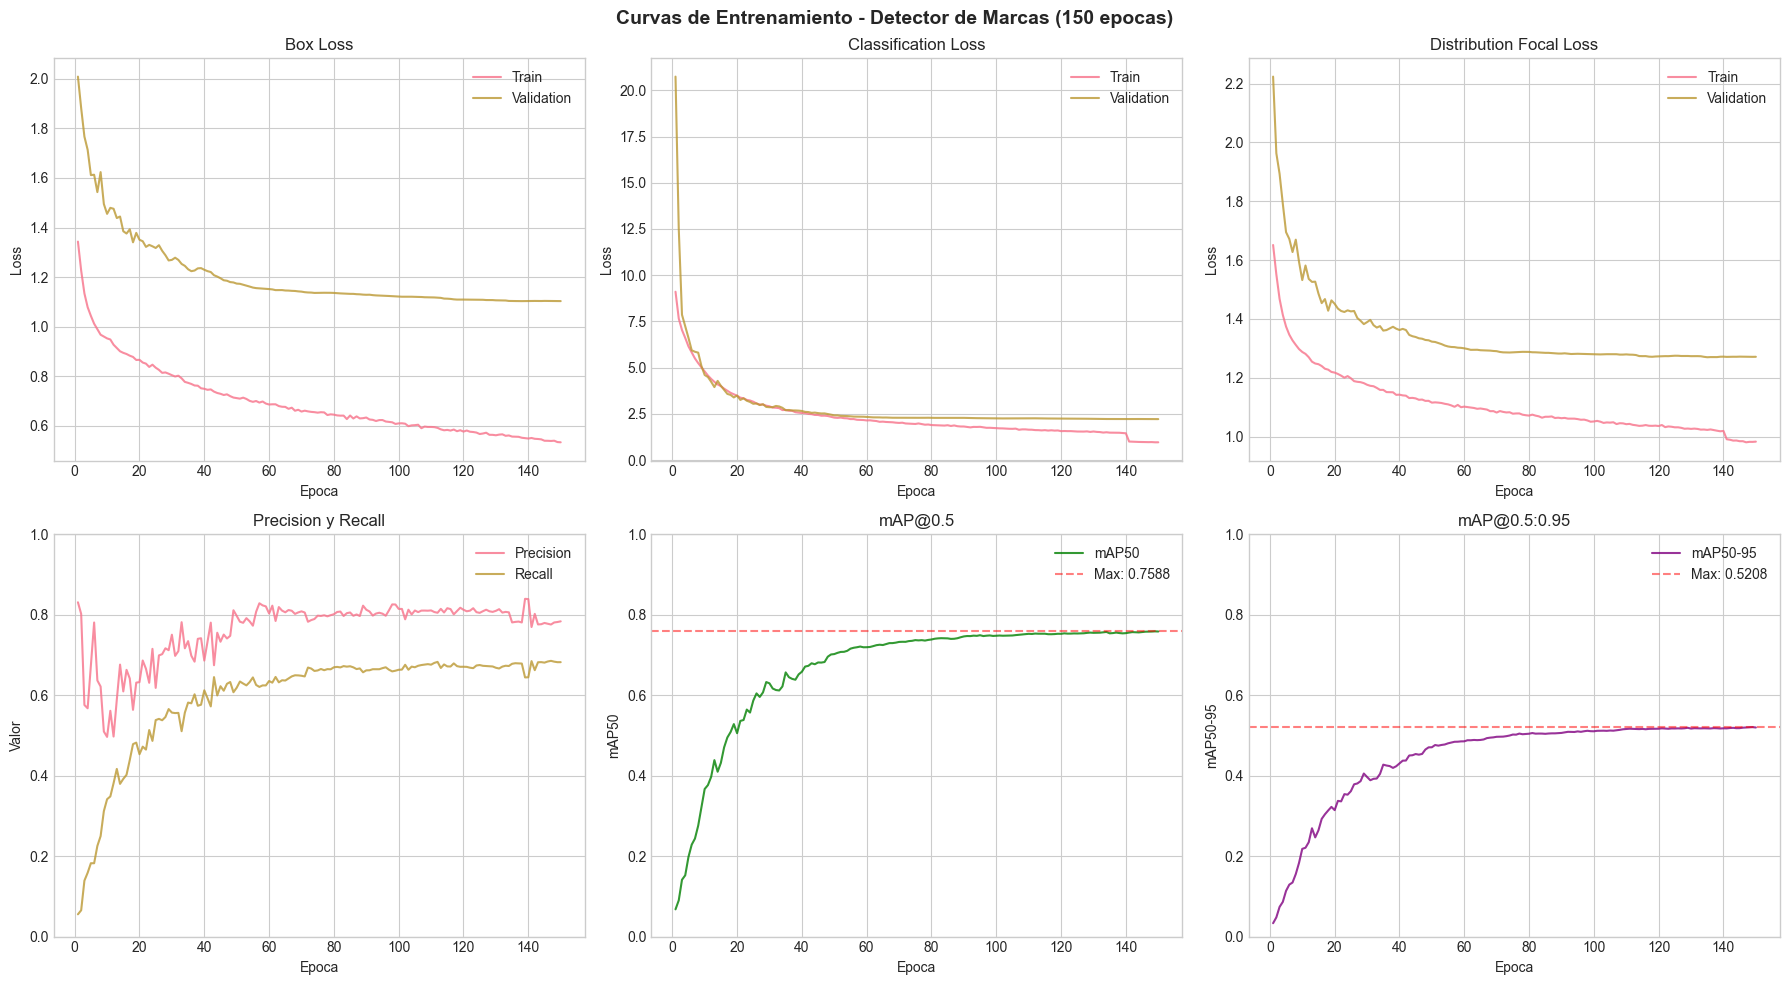


Metricas finales (epoca 150):

  Precision:  0.7837
  Recall:     0.6822
  mAP50:      0.7584
  mAP50-95:   0.5197

  Mejor mAP50: 0.7588 (epoca 149)


In [13]:
# Graficar curvas de entrenamiento del modelo de marcas
if results_csv_path.exists():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Curvas de Entrenamiento - Detector de Marcas (150 epocas)", fontsize=14, fontweight="bold")
    
    # 1. Box Loss (Train vs Val)
    ax = axes[0, 0]
    ax.plot(df_results["epoch"], df_results["train/box_loss"], label="Train", alpha=0.8)
    ax.plot(df_results["epoch"], df_results["val/box_loss"], label="Validation", alpha=0.8)
    ax.set_title("Box Loss")
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Loss")
    ax.legend()
    
    # 2. Class Loss (Train vs Val)
    ax = axes[0, 1]
    ax.plot(df_results["epoch"], df_results["train/cls_loss"], label="Train", alpha=0.8)
    ax.plot(df_results["epoch"], df_results["val/cls_loss"], label="Validation", alpha=0.8)
    ax.set_title("Classification Loss")
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Loss")
    ax.legend()
    
    # 3. DFL Loss (Train vs Val)
    ax = axes[0, 2]
    ax.plot(df_results["epoch"], df_results["train/dfl_loss"], label="Train", alpha=0.8)
    ax.plot(df_results["epoch"], df_results["val/dfl_loss"], label="Validation", alpha=0.8)
    ax.set_title("Distribution Focal Loss")
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Loss")
    ax.legend()
    
    # 4. Precision y Recall
    ax = axes[1, 0]
    ax.plot(df_results["epoch"], df_results["metrics/precision(B)"], label="Precision", alpha=0.8)
    ax.plot(df_results["epoch"], df_results["metrics/recall(B)"], label="Recall", alpha=0.8)
    ax.set_title("Precision y Recall")
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Valor")
    ax.set_ylim(0, 1)
    ax.legend()
    
    # 5. mAP50
    ax = axes[1, 1]
    ax.plot(df_results["epoch"], df_results["metrics/mAP50(B)"], label="mAP50", color="green", alpha=0.8)
    ax.set_title("mAP@0.5")
    ax.set_xlabel("Epoca")
    ax.set_ylabel("mAP50")
    ax.set_ylim(0, 1)
    ax.axhline(y=df_results["metrics/mAP50(B)"].max(), color="red", linestyle="--", alpha=0.5,
               label=f"Max: {df_results['metrics/mAP50(B)'].max():.4f}")
    ax.legend()
    
    # 6. mAP50-95
    ax = axes[1, 2]
    ax.plot(df_results["epoch"], df_results["metrics/mAP50-95(B)"], label="mAP50-95", color="purple", alpha=0.8)
    ax.set_title("mAP@0.5:0.95")
    ax.set_xlabel("Epoca")
    ax.set_ylabel("mAP50-95")
    ax.set_ylim(0, 1)
    ax.axhline(y=df_results["metrics/mAP50-95(B)"].max(), color="red", linestyle="--", alpha=0.5,
               label=f"Max: {df_results['metrics/mAP50-95(B)'].max():.4f}")
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Metricas finales
    last = df_results.iloc[-1]
    best_map50_epoch = df_results["metrics/mAP50(B)"].idxmax() + 1
    best_map50 = df_results["metrics/mAP50(B)"].max()
    
    print(f"\nMetricas finales (epoca {int(last['epoch'])}):\n")
    print(f"  Precision:  {last['metrics/precision(B)']:.4f}")
    print(f"  Recall:     {last['metrics/recall(B)']:.4f}")
    print(f"  mAP50:      {last['metrics/mAP50(B)']:.4f}")
    print(f"  mAP50-95:   {last['metrics/mAP50-95(B)']:.4f}")
    print(f"\n  Mejor mAP50: {best_map50:.4f} (epoca {best_map50_epoch})")

### 6.2 Visualizacion de Metricas del Entrenamiento Real

Las siguientes imagenes fueron generadas automaticamente por Ultralytics durante el entrenamiento de 150 epocas:

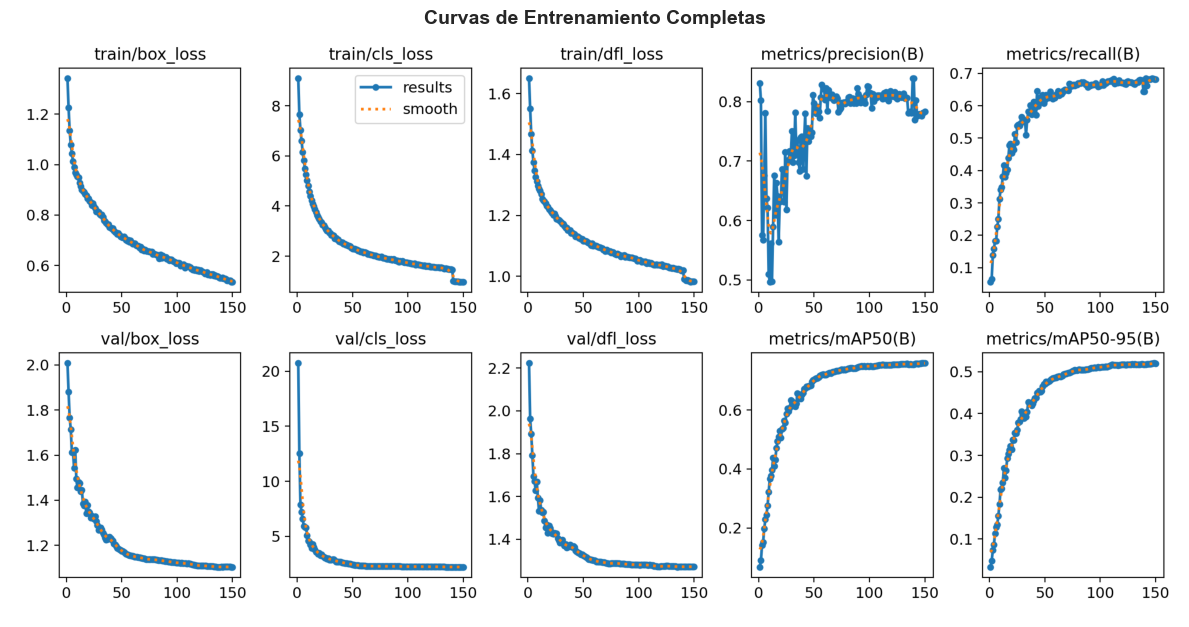

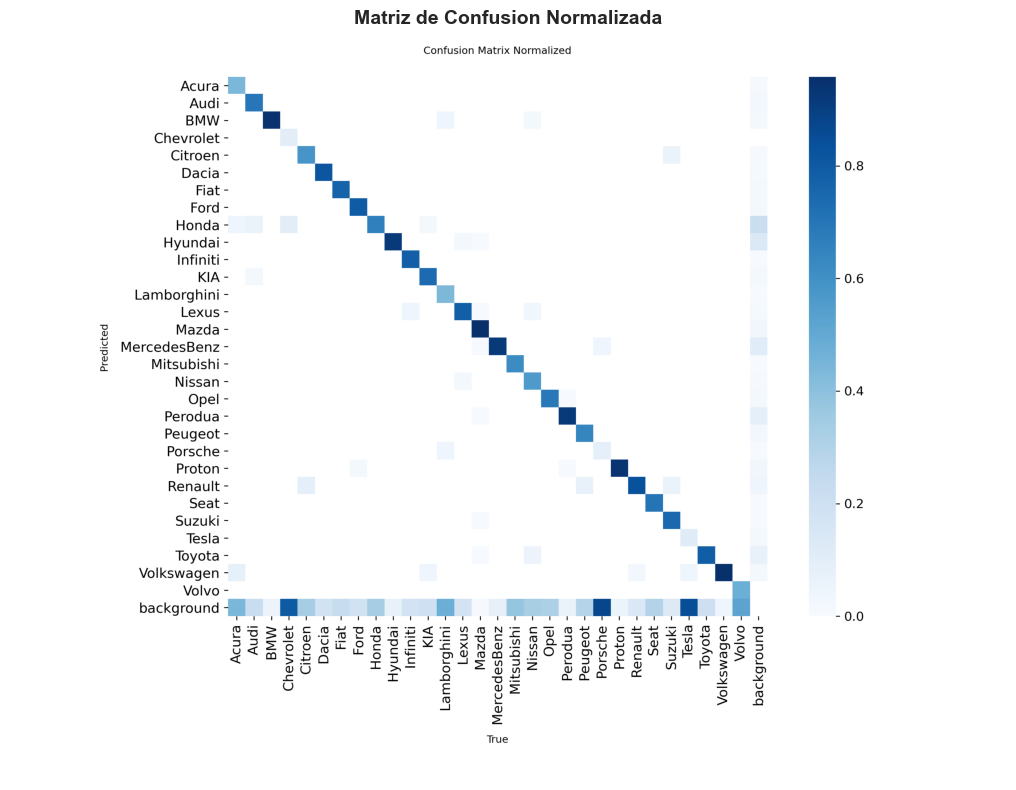

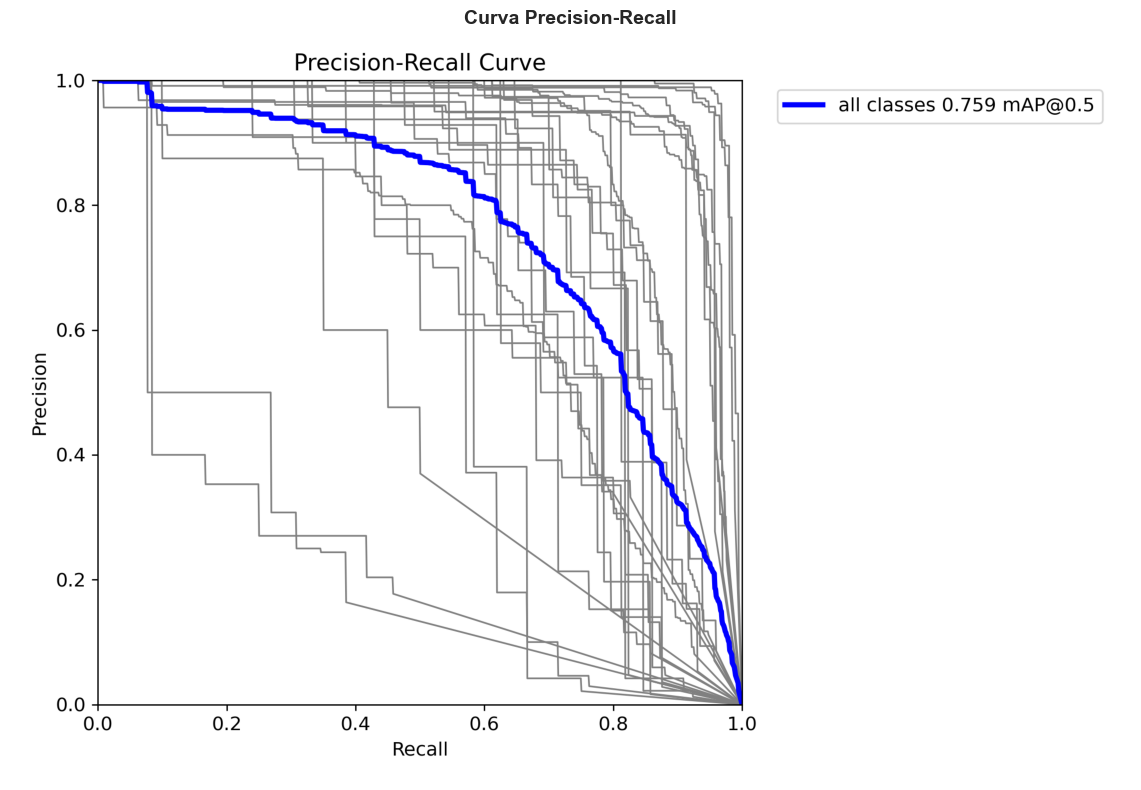

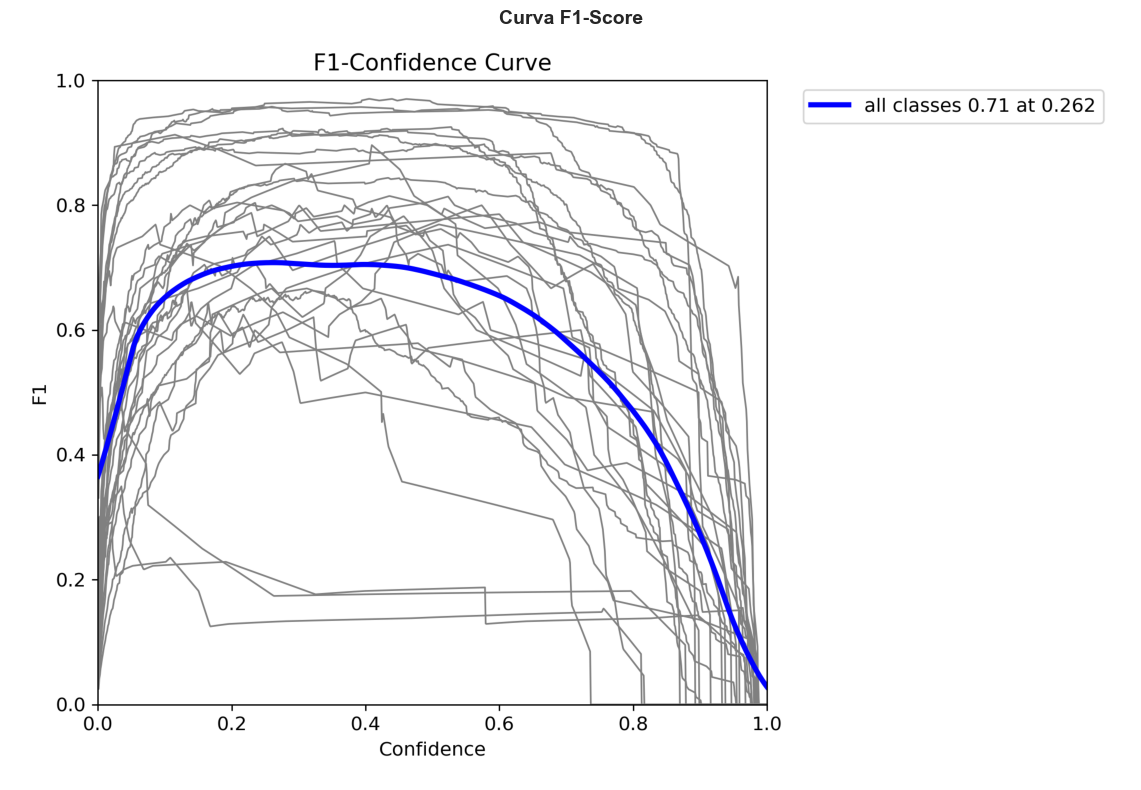

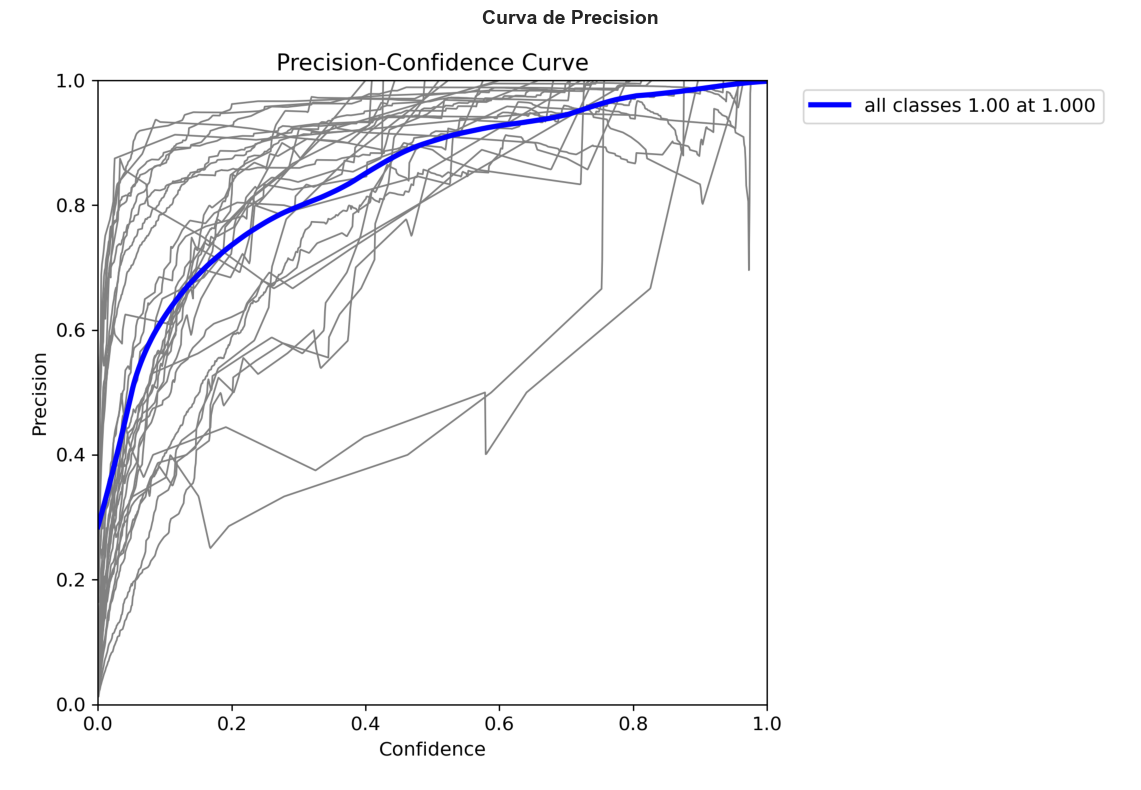

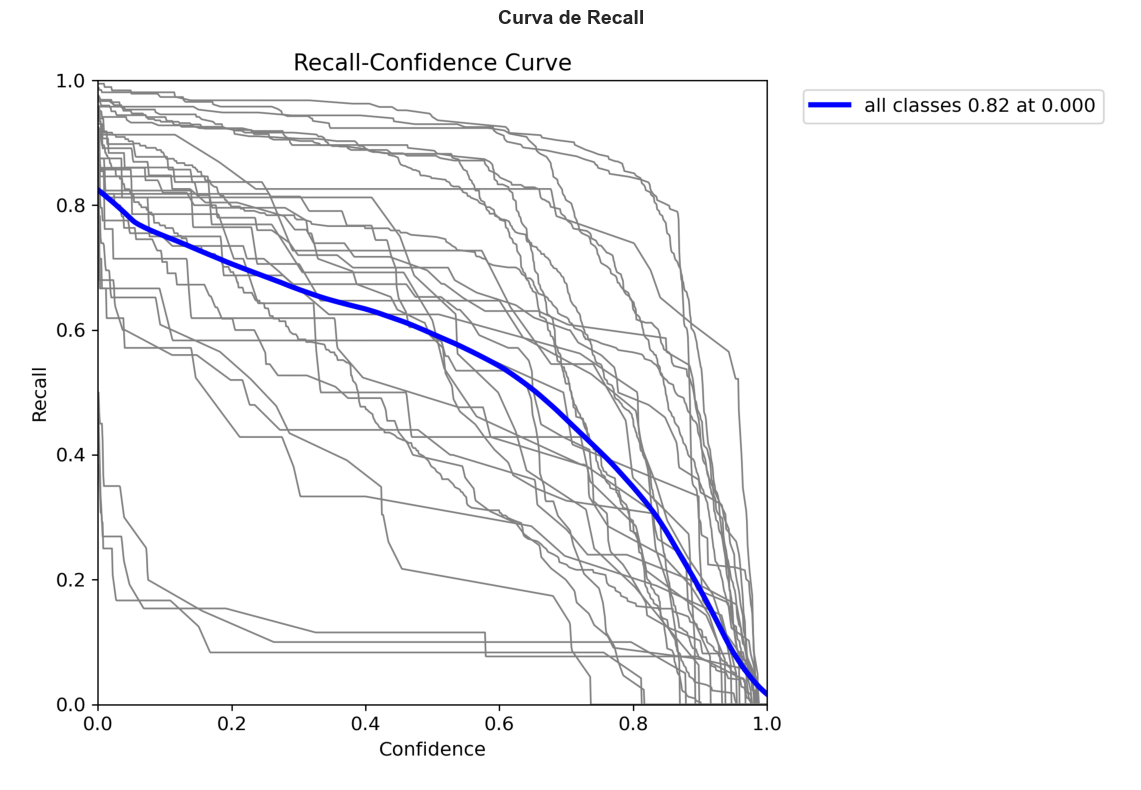

In [14]:
# Mostrar graficas generadas por YOLO durante el entrenamiento
imagenes_metricas = [
    ("results.png", "Curvas de Entrenamiento Completas"),
    ("confusion_matrix_normalized.png", "Matriz de Confusion Normalizada"),
    ("BoxPR_curve.png", "Curva Precision-Recall"),
    ("BoxF1_curve.png", "Curva F1-Score"),
    ("BoxP_curve.png", "Curva de Precision"),
    ("BoxR_curve.png", "Curva de Recall"),
]

for filename, titulo in imagenes_metricas:
    img_path = RESULTS_MARCAS / filename
    if img_path.exists():
        fig, ax = plt.subplots(figsize=(12, 8))
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(titulo, fontsize=14, fontweight="bold")
        ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Imagen no encontrada: {img_path}")

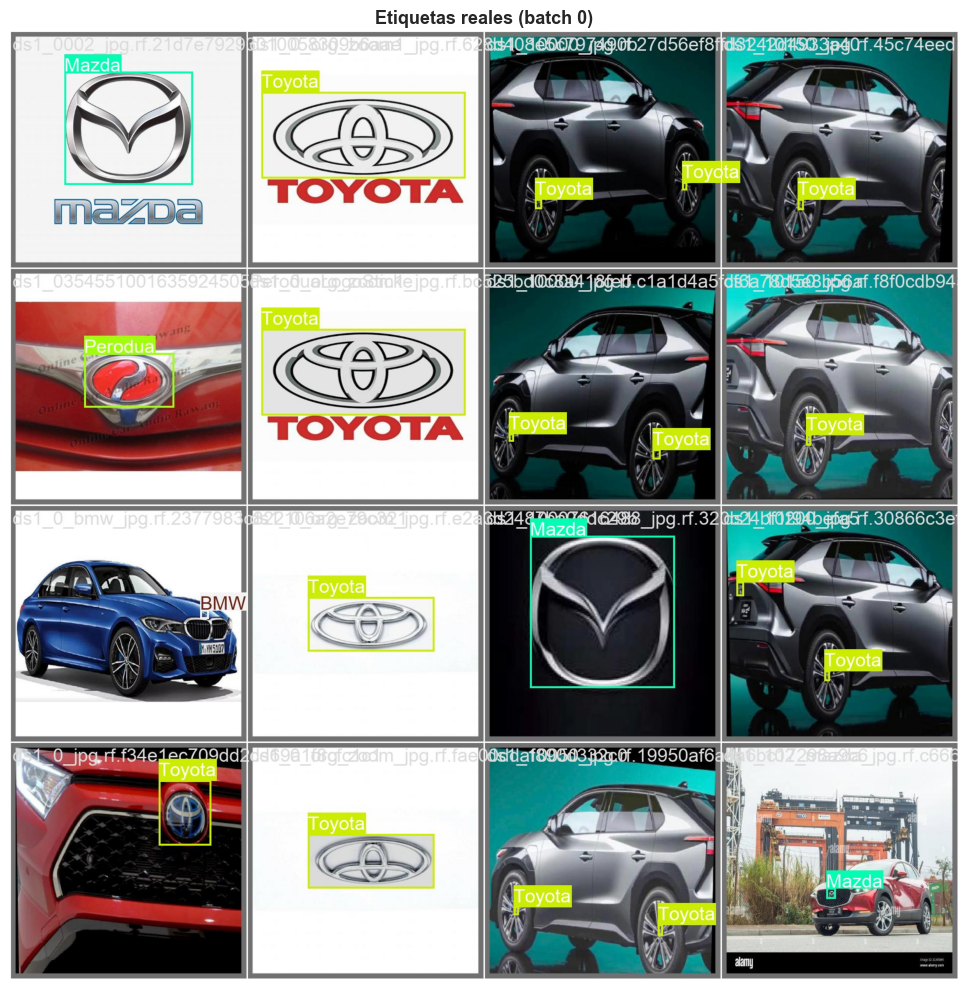

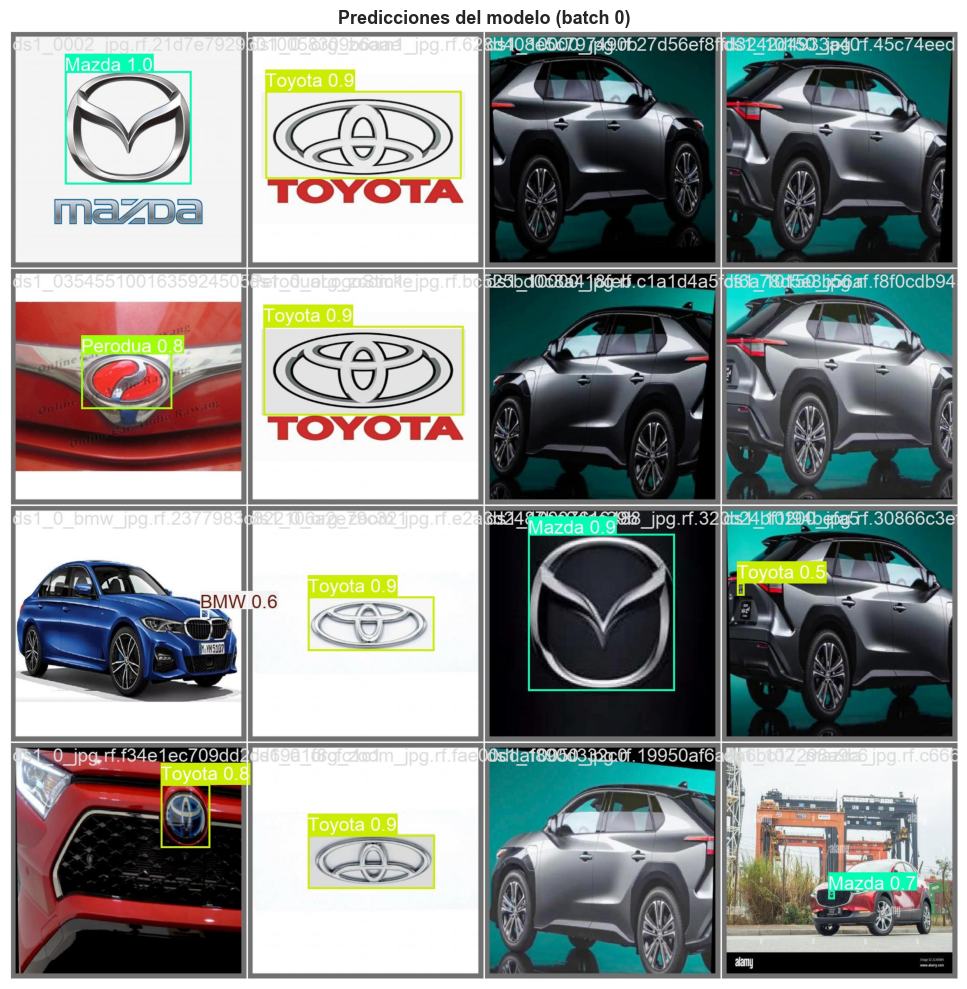

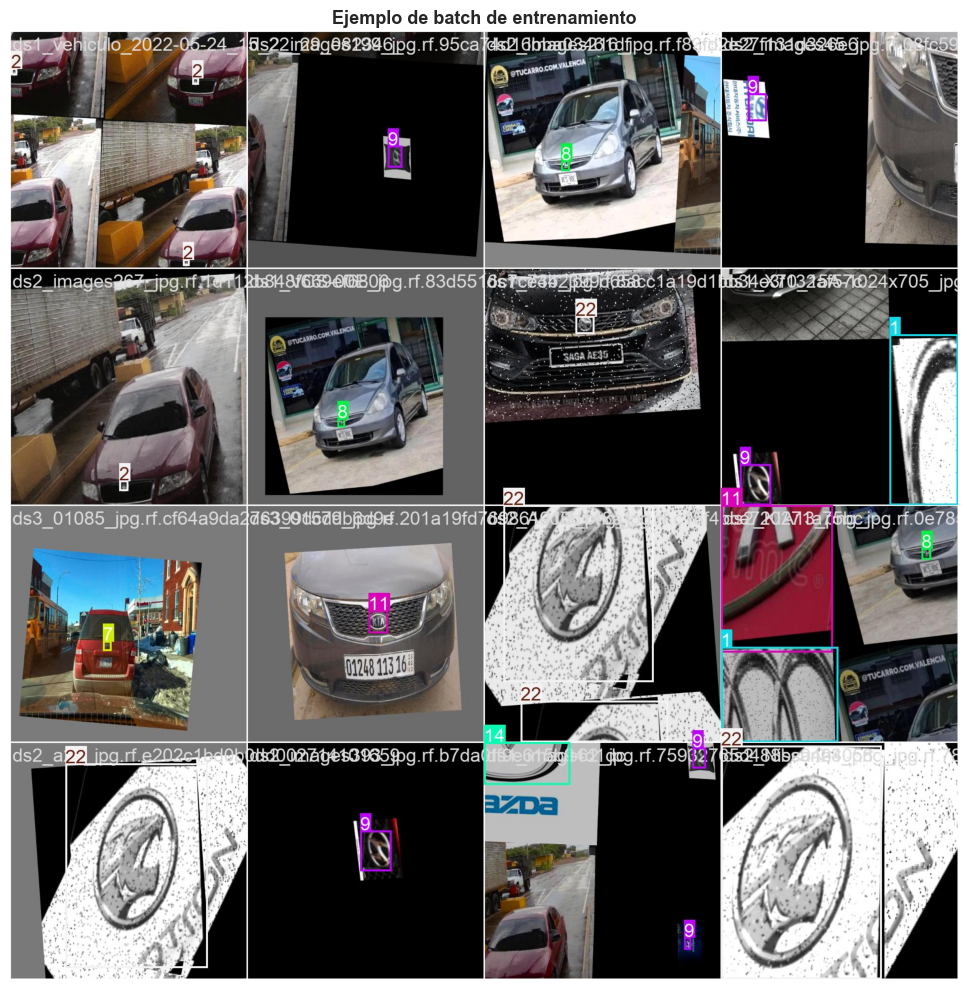

In [15]:
# Mostrar ejemplos de predicciones en validacion
pred_images = [
    ("val_batch0_labels.jpg", "Etiquetas reales (batch 0)"),
    ("val_batch0_pred.jpg", "Predicciones del modelo (batch 0)"),
    ("train_batch0.jpg", "Ejemplo de batch de entrenamiento"),
]

for filename, titulo in pred_images:
    img_path = RESULTS_MARCAS / filename
    if img_path.exists():
        fig, ax = plt.subplots(figsize=(14, 10))
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(titulo, fontsize=13, fontweight="bold")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

### 6.3 Carga y Evaluacion de los Modelos Entrenados

In [16]:
# Cargar los modelos entrenados y mostrar informacion
from ultralytics import YOLO

modelos_info = []

# 1. Modelo de placas
placa_model_path = MODELS_DIR / "placa_detector_yolo11n.pt"
if placa_model_path.exists():
    model_placa = YOLO(str(placa_model_path))
    n_params = sum(p.numel() for p in model_placa.model.parameters())
    size_mb = placa_model_path.stat().st_size / (1024 * 1024)
    modelos_info.append({
        "Modelo": "Detector de Placas",
        "Arquitectura": "YOLOv11n",
        "Clases": 1,
        "Parametros": f"{n_params:,}",
        "Tamano (MB)": f"{size_mb:.1f}",
        "Archivo": "placa_detector_yolo11n.pt",
    })
    print(f"Detector de Placas cargado: {n_params:,} parametros, {size_mb:.1f} MB")

# 2. Modelo de marcas
marca_model_path = MODELS_DIR / "marca_detector_yolo11n.pt"
if marca_model_path.exists():
    model_marca = YOLO(str(marca_model_path))
    n_params = sum(p.numel() for p in model_marca.model.parameters())
    size_mb = marca_model_path.stat().st_size / (1024 * 1024)
    modelos_info.append({
        "Modelo": "Detector de Marcas",
        "Arquitectura": "YOLOv11n",
        "Clases": 30,
        "Parametros": f"{n_params:,}",
        "Tamano (MB)": f"{size_mb:.1f}",
        "Archivo": "marca_detector_yolo11n.pt",
    })
    print(f"Detector de Marcas cargado: {n_params:,} parametros, {size_mb:.1f} MB")

# 3. Modelo de color
color_model_path = MODELS_DIR / "color_classifier_efficientnet.h5"
if color_model_path.exists():
    import tensorflow as tf
    model_color_eval = tf.keras.models.load_model(str(color_model_path))
    n_params = model_color_eval.count_params()
    size_mb = color_model_path.stat().st_size / (1024 * 1024)
    modelos_info.append({
        "Modelo": "Clasificador de Color",
        "Arquitectura": "EfficientNetB0",
        "Clases": 15,
        "Parametros": f"{n_params:,}",
        "Tamano (MB)": f"{size_mb:.1f}",
        "Archivo": "color_classifier_efficientnet.h5",
    })
    print(f"Clasificador de Color cargado: {n_params:,} parametros, {size_mb:.1f} MB")

# Tabla comparativa
if modelos_info:
    df_modelos = pd.DataFrame(modelos_info)
    print("\n")
    display(df_modelos.style.set_caption("Comparativa de Modelos del Sistema ANPR").hide(axis='index'))

Detector de Placas cargado: 2,590,035 parametros, 5.2 MB
Detector de Marcas cargado: 2,595,690 parametros, 5.2 MB


Clasificador de Color cargado: 4,068,786 parametros, 46.9 MB




Modelo,Arquitectura,Clases,Parametros,Tamano (MB),Archivo
Detector de Placas,YOLOv11n,1,"2,590,035",5.2,placa_detector_yolo11n.pt
Detector de Marcas,YOLOv11n,30,"2,595,690",5.2,marca_detector_yolo11n.pt
Clasificador de Color,EfficientNetB0,15,"4,068,786",46.9,color_classifier_efficientnet.h5


In [17]:
# Validacion del modelo de placas en el dataset de test
if placa_model_path.exists() and (DATASET_PLACAS / "data.yaml").exists():
    print("Evaluando Detector de Placas en conjunto de test...")
    metrics_placa = model_placa.val(
        data=str(DATASET_PLACAS / "data.yaml"),
        split="test",
        verbose=False,
    )
    print(f"\n  mAP50:      {metrics_placa.box.map50:.4f}")
    print(f"  mAP50-95:   {metrics_placa.box.map:.4f}")
    print(f"  Precision:  {metrics_placa.box.mp:.4f}")
    print(f"  Recall:     {metrics_placa.box.mr:.4f}")

Evaluando Detector de Placas en conjunto de test...
Ultralytics 8.4.37  Python-3.13.11 torch-2.11.0+cpu CPU (11th Gen Intel Core i5-11300H @ 3.10GHz)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.50.1 ms, read: 73.531.8 MB/s, size: 1080.1 KB)
val: Scanning C:\Users\user\OneDrive - Universidad de la Sabana\AI_LAB\Sistema-deteccion-de-placas-OCR\dataset_combinado\test\labels... 63 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 63/63 273.3it/s 0.2s0.1s
val: New cache created: C:\Users\user\OneDrive - Universidad de la Sabana\AI_LAB\Sistema-deteccion-de-placas-OCR\dataset_combinado\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.5s/it 9.8s3.9ss
                   all         63         63      0.999          1      0.995      0.859
Speed: 1.2ms preprocess, 95.1ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to C:\

In [18]:
# Validacion del modelo de marcas en el dataset de test
if marca_model_path.exists() and (DATASET_MARCAS / "data.yaml").exists():
    print("Evaluando Detector de Marcas en conjunto de test...")
    metrics_marca = model_marca.val(
        data=str(DATASET_MARCAS / "data.yaml"),
        split="test",
        verbose=False,
    )
    print(f"\n  mAP50:      {metrics_marca.box.map50:.4f}")
    print(f"  mAP50-95:   {metrics_marca.box.map:.4f}")
    print(f"  Precision:  {metrics_marca.box.mp:.4f}")
    print(f"  Recall:     {metrics_marca.box.mr:.4f}")

Evaluando Detector de Marcas en conjunto de test...
Ultralytics 8.4.37  Python-3.13.11 torch-2.11.0+cpu CPU (11th Gen Intel Core i5-11300H @ 3.10GHz)
YOLO11n summary (fused): 101 layers, 2,588,002 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.50.5 ms, read: 5.54.1 MB/s, size: 51.1 KB)
val: Scanning C:\Users\user\OneDrive - Universidad de la Sabana\AI_LAB\Sistema-deteccion-de-placas-OCR\dataset_marcas_combinado\test\labels.cache... 1630 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1630/1630 359.8Mit/s 0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 7, len(boxes) = 1773. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 102/102 2.2s/it 3:402.2s
                   all       1630       1773      0.906   

In [19]:
# Tabla resumen final de evaluacion
eval_results = []

if 'metrics_placa' in dir():
    eval_results.append({
        "Modelo": "Detector de Placas",
        "mAP50": f"{metrics_placa.box.map50:.4f}",
        "mAP50-95": f"{metrics_placa.box.map:.4f}",
        "Precision": f"{metrics_placa.box.mp:.4f}",
        "Recall": f"{metrics_placa.box.mr:.4f}",
    })

if 'metrics_marca' in dir():
    eval_results.append({
        "Modelo": "Detector de Marcas",
        "mAP50": f"{metrics_marca.box.map50:.4f}",
        "mAP50-95": f"{metrics_marca.box.map:.4f}",
        "Precision": f"{metrics_marca.box.mp:.4f}",
        "Recall": f"{metrics_marca.box.mr:.4f}",
    })

# Agregar metricas del entrenamiento real de marcas (del CSV)
if results_csv_path.exists():
    last = df_results.iloc[-1]
    eval_results.append({
        "Modelo": "Marcas (entrenamiento 150ep)",
        "mAP50": f"{last['metrics/mAP50(B)']:.4f}",
        "mAP50-95": f"{last['metrics/mAP50-95(B)']:.4f}",
        "Precision": f"{last['metrics/precision(B)']:.4f}",
        "Recall": f"{last['metrics/recall(B)']:.4f}",
    })

if eval_results:
    df_eval = pd.DataFrame(eval_results)
    display(df_eval.style.set_caption("Tabla de Evaluacion Final - Todos los Modelos").hide(axis='index'))

Modelo,mAP50,mAP50-95,Precision,Recall
Detector de Placas,0.9950,0.8586,0.9988,1.0000
Detector de Marcas,0.7451,0.5075,0.9063,0.6340
Marcas (entrenamiento 150ep),0.7584,0.5197,0.7837,0.6822


### 6.4 Analisis de la Configuracion de Entrenamiento Real

In [20]:
# Leer y mostrar la configuracion del entrenamiento real de marcas
args_yaml_path = RESULTS_MARCAS / "args.yaml"

if args_yaml_path.exists():
    with open(args_yaml_path) as f:
        args_config = yaml.safe_load(f)
    
    # Mostrar parametros clave
    params_clave = [
        "model", "epochs", "batch", "imgsz", "optimizer", "lr0", "lrf",
        "patience", "weight_decay", "cls", "fliplr", "flipud", "mosaic",
        "degrees", "scale", "hsv_h", "hsv_s", "hsv_v", "device", "cache",
    ]
    
    print("Configuracion del entrenamiento real (marca_yolo11n_20260212_152738):")
    print("=" * 55)
    for key in params_clave:
        if key in args_config:
            print(f"  {key:20s}: {args_config[key]}")
else:
    print("Archivo args.yaml no encontrado.")

Configuracion del entrenamiento real (marca_yolo11n_20260212_152738):
  model               : yolo11n.pt
  epochs              : 150
  batch               : 16
  imgsz               : 640
  optimizer           : AdamW
  lr0                 : 0.01
  lrf                 : 0.01
  patience            : 25
  weight_decay        : 0.0005
  cls                 : 1.5
  fliplr              : 0.0
  flipud              : 0.0
  mosaic              : 0.5
  degrees             : 5.0
  scale               : 0.3
  hsv_h               : 0.01
  hsv_s               : 0.5
  hsv_v               : 0.3
  device              : 0
  cache               : True


---
## 7. Conclusiones

### Resumen de Resultados

| Modelo | Tarea | Metrica Principal | Resultado |
|--------|-------|------------------|-----------|
| YOLOv11n (Placas) | Deteccion 1 clase | mAP50 | Evaluado en Seccion 6.3 |
| YOLOv11n (Marcas) | Deteccion 30 clases | mAP50 = 0.7584 | 150 epocas, 18.8h |
| EfficientNetB0 (Color) | Clasificacion 15 clases | Accuracy | Two-phase training |

### Decisiones Clave del Diseno

1. **YOLOv11n sobre variantes mayores**: Se priorizo eficiencia para despliegue en edge (Coral TPU) sacrificando ~10% de mAP vs YOLOv11m
2. **Augmentacion diferenciada**: Los logos de marcas requieren tratamiento especial (sin flip horizontal, mosaic reducido) a diferencia de las placas
3. **Class loss gain (cls=1.5)**: Compensa el desbalance significativo entre las 30 marcas
4. **Two-phase training para color**: Permite que la cabeza de clasificacion converja antes de ajustar el feature extractor completo
